# Лабораторная работа

Баллы за секции:
- *Задание 1* - 10 баллов
- *Задание 2* - 20 баллов
- *Задание 3* - 30 баллов
- **Итого** - 60 баллов

Оценка за лабу $ = \frac{score}{6}$

## Внимание! Attention! Achtung!

**Данная лабораторная работа является блокирующей**, т.е. если лабораторная работа не выполнена, то оценка за курс - неуд.

Лабораторная работа считается выполненной, если **за каждое из заданий получено не менее 2 баллов**.

## Формат сдачи лабораторной работы

Данная лабораторная работа сдается так же, как и проект - заполняете данный ноутбук, отправляете его через GitHub с указанием проверяющего.

**Ассистенты не будут запускать ячейки кода, а смотреть на выведенный результат и код. Если ячейка кода не запущена - балл не ставится, даже при правильно написанном коде.**

***(Комментарии что курс по Python легче чем по C++ учтены)***

>**Примечание**
>
>Данные задания вдохновлены предметом "Введение в анализ данных" 2 курса, по итогу которого идёт отбор на DS-поток. Если вы видите себя в смежных областях, советуем выполнить данную лабораторку по максимуму.

In [ ]:
# Всё необходимое для выполнения данной лабораторной работы!
import requests
from time import sleep

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopy.distance
import plotly.express as px
from sklearn.model_selection import train_test_split

## Задание 1. Парсинг - 10 баллов

В этом задании Вам предстоит работать с API сайта <a target="_blank" href="hh.ru">hh.ru</a>. Документация доступна по <a target="_blank" href="https://github.com/hhru/api/blob/master/docs/vacancies.md#search">ссылке</a>.

<b><font color="red">Внимание!</font> При работе с API не забывайте делать паузы между запросами, иначе вас забанят. Просрочка дедлайна по этой причине не принимается!</b>

**Задача:**
1. выбрать 5 интересующих вас профессий (не смежных, т.е. Аналатик и Data Engineer не считается корректным)
2. затем получить доступные по данным профессиям вакансии в Москве и выделить их физические координаты
3. нанести полученные координаты на карту местоположения компаний

*Пример запроса для профессии:*

In [ ]:
URL = 'https://api.hh.ru/vacancies'

params = {
    'text': "Физик-ядерщик",
    'area': 1,
    'page': 0,
    'per_page': 10
}

data = requests.get(URL, params).json()

Если Ваш запрос прошел успешно, то вы получите следующие ключи (значения данных ключей вы найдете по ссылке на документацию):

In [ ]:
data.keys()

dict_keys(['items', 'found', 'pages', 'page', 'per_page', 'clusters', 'arguments', 'fixes', 'suggests', 'alternate_url'])

>**Примечание**
>
>В `data['pages']` будет хранится количество найденных страниц вакансий - для корректного сбора данных Вам нужно пробежать по **КАЖДОЙ** странице и сделать соотвествующие запросы.

>**Совет**
>
>Посмотрите что хранится в `items`!

(1 балл) Выберете для нас 5 наиболее интересных специальностей и получите по ним имеющиеся вакансии:

In [ ]:
professions = [
    "Танцовщица",
    "Аналитик",
    "Охранник",
    "Повар",
    "Водитель",
]

all_vacancies = {}

for profession in professions:
    params = {
        'text': profession,
        'area': 1,
        'page': 0,
        'per_page': 10
    }
    all_vacancies[profession] = list()
    data = requests.get(URL, params).json()
    if 'pages' not in data:
        continue
    pages = data['pages']
    while params['page'] < pages:
        data = requests.get(URL, params).json()
        if 'items' in data:
            all_vacancies[profession].extend(data['items'])
        params['page'] += 1
        sleep(0.2)


(1 балл) Посчитайте сколько всего найдено вакансий:

In [ ]:
vacancies_count = 0
for profffesion in professions:
    vacancies_count += len(all_vacancies[profffesion])
print(vacancies_count)


6864


(1 балл) Создайте структуру данных, которая будет хранить в себе имя компании и ее координаты (широта и долгота):

In [ ]:
class Company:
    def __init__(self, name, latitude, longitude):
        self.name = name
        self.latitude = latitude
        self.longitude = longitude


(1 балл) Создайте экземпляр этой структуры данных для каждой компании, которая выставила вакансию:

In [ ]:
companies = dict()

for vacancies in all_vacancies.values():
    for vacancy in vacancies:
        if "employer" in vacancy:
            employer = vacancy["employer"]
            if "id" in employer:
                my_id = employer["id"]
                address = vacancy.get("address", {})
                if address is None:
                    address = {}
                companies[my_id] = Company(name=employer["name"],
                                        latitude=address.get("lat", None),
                                        longitude=address.get("lng", None))


(1 балл) Найдите количество вакансий, у которых заданы координаты (значения данных может быть пустым):

In [ ]:
companies_count = 0
for company in companies.values():
    if company.latitude is not None and company.longitude is not None:
        companies_count += 1
companies_count


2676

(1 балл) Отберите вакансии, которые расположены в пределах МКАД (можно грубо):

In [ ]:
latitude_min, longitude_min = 55.59, 37.38
latitude_max, longitude_max = 55.91, 37.82


mkad_companies = dict()
for key in companies:
    if companies[key].longitude is not None and companies[key].latitude is not None:
        if longitude_min < companies[key].longitude < longitude_max and latitude_min < companies[key].latitude < latitude_max:
            mkad_companies[key] = companies[key]

print(f"Количество компании в пределах МКАД = {len(mkad_companies.values())}")

Количество компании в пределах МКАД = 2244


(1 балл) Постройте график в координатах "широта-долгота" для отображения вакансий внутри МКАД (не забывайте прописать прозрачность, чтобы увидеть скопления):

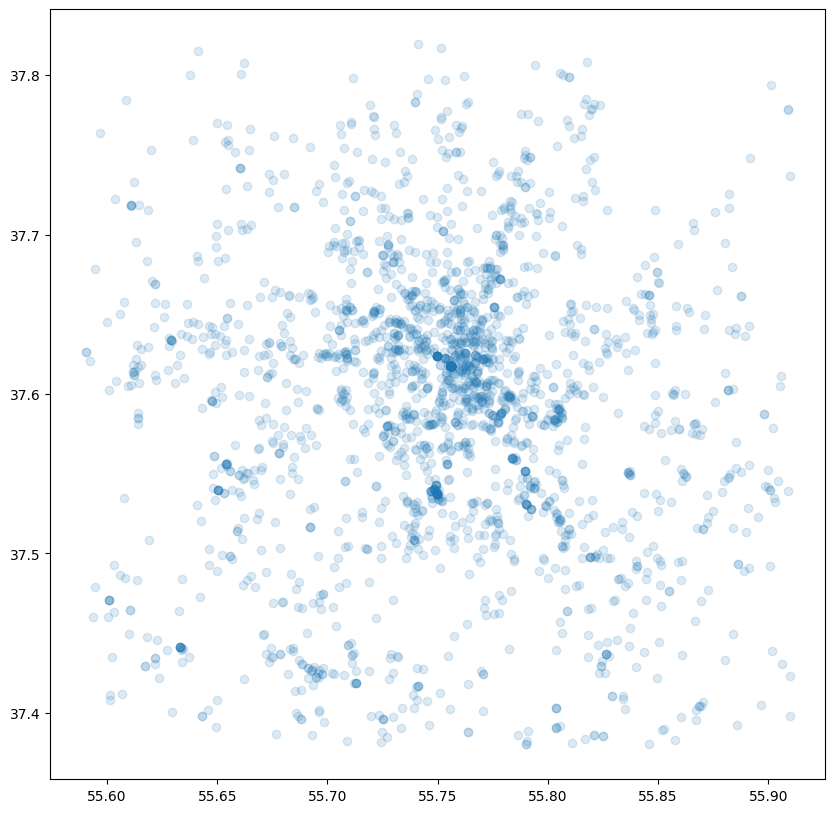

In [ ]:
x = []
y = []
for company in mkad_companies.values():
    x.append(company.latitude)
    y.append(company.longitude)

plt.figure(figsize=(10, 10))
plt.scatter(x = x, y = y, alpha = 0.15)

(1 балл) Нанесите все точки вакансий на карту (для этого вам поможет данная <a target="_blank" href="https://plotly.com/python/mapbox-layers/">документации</a>, не забудьте про прозрачность и центрирование по Москве):

In [ ]:
m_lat= 55.755831
m_lon = 37.617673

df = pd.DataFrame({
    "latitude": x,
    "longitude": y,
})

fig = px.scatter_mapbox(df, lat="latitude", lon="longitude", zoom=10, height=500)

# Настраиваем стиль карты и центрируем по Москве
fig.update_layout(
    mapbox_style="open-street-map",
    mapbox_center={"lat": m_lat, "lon": m_lon},
)

# Отображаем график
fig.show()
# Сохраняем график в файл HTML внутри ноутбука
fig.write_html("map.html")

(2 балла) **Сделайте выводы о проделанной работе:**

>*Подсказки для маленьких: Что вы можете сказать про районы Москвы? Что вы можете сказать про зарплаты? Что вы можете сказать про спрос?*

Ваши выводы здесь :)

## Задание 2. Анализ данных - 20 баллов

Вам предстоит проанализировать датасет, содержащий информацию об бриллианта, их стоимости и остальных характеристиках.



Поясним значения хранящиеся в колонках:
*   `cut` - огранка бриллианта (относится к одной из примерно 10 наиболее распространенных)
*   `color` - цвет бриллианта, прозрачные бриллианты имеют градацию `D-Z`, "более высокие" буквы - более желтоватые, но часто имеют лучшие значения, поскольку цвет трудно определить один раз в кольце
*   `clarity` - чистота бриллианта, наличие включений (внутренних дефектов), чем меньше и мельче, тем лучше
*   `carat_weight` - масса бриллианта (слабо связана с размером бриллианта, т.к. огранка и качество огранки, как правило, играют большую роль)
*   `cut_quality` - качество ограники по системе оценки GIA Cut
*   `lab` - лаборатория оценивания
*   `meas_length` - длина бриллианта
*   `meas_width` - ширина бриллианта
*   `meas_depth` - глубина бриллианта
*   `total_sales_price` - цена бриллианта в долларах.
*    **и прочие колонки**

Скачаем данные:

In [ ]:
!gdown 10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8

Downloading...
From: https://drive.google.com/uc?id=10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8
To: /content/diamonds.csv
100% 35.4M/35.4M [00:00<00:00, 196MB/s]


Создадим DataFrame:

In [ ]:
import pandas as pd

diamonds_df = pd.read_csv("diamonds.csv")
diamonds_df

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219698,219699,Round,E,VS1,10.65,Excellent,GIA,Excellent,Excellent,unknown,...,8.66,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,1210692
219699,219700,Radiant,unknown,VS2,5.17,unknown,GIA,Very Good,Very Good,unknown,...,5.71,TK,XTK,unknown,NaN,Green,unknown,NaN,Fancy Light,1292500
219700,219701,Round,E,VS1,18.07,Excellent,GIA,Excellent,Excellent,unknown,...,10.20,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,1315496
219701,219702,Princess,unknown,SI2,0.90,unknown,GIA,Good,Good,unknown,...,3.47,XTN,VTK,unknown,Faint,Red,unknown,unknown,Fancy,1350000


(0.5 балла) Выведете первые 5 строк датасета:

In [ ]:
diamonds_df.head()

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200


(0.5 балла) Найдите количество бриллиантов всего в данном датасете:

In [ ]:
print(diamonds_df.shape[0])

219703


(0.5 балла) Выведите максимальную и минимальную цену бриллианта в формате `номер - цена`:

In [ ]:
max_ind = diamonds_df['total_sales_price'].idxmax()
min_ind = diamonds_df['total_sales_price'].idxmin()

print(f"Maximal price: {max_ind} - {diamonds_df.loc[max_ind, 'total_sales_price']}")
print(f"Minimal price: {min_ind} - {diamonds_df.loc[max_ind, 'total_sales_price']}")


Maximal price: 219702 - 1449881
Minimal price: 0 - 1449881


(1 балл) Посчитайте количество пропусков (пропуском считается значение `unknown` или `None`):

In [ ]:
diamonds_df.replace(['unknown', 'None'], np.nan, inplace=True)
none = diamonds_df.isnull().sum()
print(none.sum())


1891168


(1 балл) Найдите в каких столбцах присутствуют пропуски:

In [ ]:
miss_col = diamonds_df.columns[diamonds_df.isnull().any()].tolist()
print(miss_col)

['color', 'cut_quality', 'eye_clean', 'culet_size', 'culet_condition', 'girdle_min', 'girdle_max', 'fluor_color', 'fluor_intensity', 'fancy_color_dominant_color', 'fancy_color_secondary_color', 'fancy_color_overtone', 'fancy_color_intensity']


В нашем датасете присутствуют колонки, которые начинаются с `fancy_color_` или `fluor_`. Большинство значений в этих колонках - `unknown` или `None`, поэтому мы считаем их малоинформативными.

Ваша задача:

1. (0.5 балла) найти количество таких колонок, которые начинаются с `fancy_color_` или `fluor_`:

In [ ]:
columns_count = sum(col.startswith('fancy_color_') or col.startswith('fluor_') for col in diamonds_df.columns)

print("Number of columns starting with fancy_color_ or fluor_:", columns_count)

Number of columns starting with fancy_color_ or fluor_: 6


2. (0.5 балла) найти количество информативных (не `None` или `unknown`) значений в этих колонках:

In [ ]:
selected_columns = [col for col in diamonds_df.columns if col.startswith('fancy_color_') or col.startswith('fluor_')]

informative_count = diamonds_df[selected_columns].apply(lambda col: col[col.isin(['None', 'unknown']) == False].count()).sum()

print("Number of informative values in selected columns:", informative_count)

Number of informative values in selected columns: 111586


3. (0.5 балла) удалить данные колонки из датасета, сохранив изменения (в дальнейшем работаем измененным датасетом):

In [ ]:
columns_to_drop = [col for col in diamonds_df.columns if col.startswith('fancy_color_') or col.startswith('fluor_')]

diamonds_df.drop(columns=columns_to_drop, inplace=True)

(1 балл) Проделайте тоже самое для колонок, начинающихся с `culet_`:

In [ ]:
count_columns_culet = sum(col.startswith('culet_') for col in diamonds_df.columns)

print("starts with culet_:", count_columns_culet)

informative_count_culet = diamonds_df.filter(like='culet_').apply(lambda col: col[col.isin(['None', 'unknown']) == False].count()).sum()

print("informative culet columns:", informative_count_culet)

starts with culet_: 2
informative culet columns: 149282


(1 балл) Посчитайте сколько бы стоил (в тысячах долларов) сейф, в котором хранились бы все бриллианты из датасета:

In [ ]:
columns_to_drop = [col for col in diamonds_df.columns if col.startswith('culet_')]

diamonds_df.drop(columns=columns_to_drop, inplace=True)

total_price = diamonds_df['total_sales_price'].sum()

total_price_in_thousands = total_price / 1000

print(total_price_in_thousands)


1517721.991


Немного необоснованных манипуляций.

(1 балл) Выберите из датасета строки с четными индексами и выведете значения (не меняя нумерацию индексов):

In [ ]:
even_index_rows = diamonds_df.iloc[::2]

print(even_index_rows)

        Unnamed: 0    cut color clarity  carat_weight cut_quality  lab  \
0                0  Round     E    VVS2          0.09   Excellent  IGI   
2                2  Round     E    VVS2          0.09   Excellent  IGI   
4                4  Round     E    VVS2          0.09   Very Good  IGI   
6                6  Round     E    VVS2          0.09   Very Good  IGI   
8                8  Round     E    VVS2          0.09   Very Good  IGI   
...            ...    ...   ...     ...           ...         ...  ...   
219694      219695  Round     D      IF         12.52   Excellent  HRD   
219696      219697   Oval     H     VS2         18.88         NaN  GIA   
219698      219699  Round     E     VS1         10.65   Excellent  GIA   
219700      219701  Round     E     VS1         18.07   Excellent  GIA   
219702      219703   Pear   NaN    VVS2         10.03         NaN  GIA   

         symmetry     polish eye_clean  depth_percent  table_percent  \
0       Very Good  Very Good       NaN 

(0.5 балла) А теперь с индексами, кратными 6:

In [ ]:
index_multiple_of_six_rows = diamonds_df.iloc[::6]

print(index_multiple_of_six_rows)

        Unnamed: 0      cut color clarity  carat_weight cut_quality  lab  \
0                0    Round     E    VVS2          0.09   Excellent  IGI   
6                6    Round     E    VVS2          0.09   Very Good  IGI   
12              12    Round     E    VVS2          0.09   Very Good  IGI   
18              18    Round     E    VVS2          0.09   Excellent  IGI   
24              24    Round     L      I1          0.34   Excellent  IGI   
...            ...      ...   ...     ...           ...         ...  ...   
219678      219679    Round     G     VS1         10.23   Excellent  GIA   
219684      219685  Radiant   NaN      I1          0.89         NaN  GIA   
219690      219691    Round     D    VVS2         10.10   Excellent  GIA   
219696      219697     Oval     H     VS2         18.88         NaN  GIA   
219702      219703     Pear   NaN    VVS2         10.03         NaN  GIA   

         symmetry     polish eye_clean  depth_percent  table_percent  \
0       Very Go

(1 балл) Выберете из датасета только категорильные признаки и выведете датасет:

In [ ]:
categorical_features = diamonds_df.select_dtypes(include=['object'])

print(categorical_features)

             cut color clarity cut_quality  lab   symmetry     polish  \
0          Round     E    VVS2   Excellent  IGI  Very Good  Very Good   
1          Round     E    VVS2   Very Good  IGI  Very Good  Very Good   
2          Round     E    VVS2   Excellent  IGI  Very Good  Very Good   
3          Round     E    VVS2   Excellent  IGI  Very Good  Very Good   
4          Round     E    VVS2   Very Good  IGI  Very Good  Excellent   
...          ...   ...     ...         ...  ...        ...        ...   
219698     Round     E     VS1   Excellent  GIA  Excellent  Excellent   
219699   Radiant   NaN     VS2         NaN  GIA  Very Good  Very Good   
219700     Round     E     VS1   Excellent  GIA  Excellent  Excellent   
219701  Princess   NaN     SI2         NaN  GIA       Good       Good   
219702      Pear   NaN    VVS2         NaN  GIA  Very Good  Excellent   

       eye_clean girdle_min girdle_max  
0            NaN          M          M  
1            NaN        STK        STK  


>**Примечание**
>
>Данный датасет можно использовать для задания 3 (с использованием `sklearn`)

(0.5 балла) Выберете столбец с данными о цене бриллиантов и домножите его на тот столбец, только транспонированный, и выведите полученную матрицу:

### Построение графиков

**Требования к графику:**

1.   График должен быть подписан
2.   Оси должны быть подписаны
3.   Должна быть легенда графика
4.   График должен быть информативным (желательно без сильных выбросов)

**Все надписи на русском языке!**

>**Примечание**
>
>График необходимо строить для очищенных данных - в них не должно быть пропусков по осям, по которым строите график. При этом **не перезатирайте** имеющийся датафрейм!

(2 балла) Постройте график `цвет бриллианта - стоимость`:

(2 балла) Постройте график `лабараторная оценка - кол-во бриллиантов`:

In [ ]:
# your code here

(2 балла) Постройте график `вес бриллианта - стоимость`:

In [ ]:
# your code here

(2 балла) Постройте график `система оценки GIA Cut - кол-во бриллиантов`:

In [ ]:
# your code here

(2 балла) **Сделайте выводы по построенным графикам:**

>*Подсказка для маленьких: Что вы можете сказать о графиках полученных выше для данного датасета?*

Ваши выводы здесь :)

## Задание 3. Модель - 30 баллов

В данном задании вам предстоит построить классифицирующую модель размер алмаза и его стоимости, а затем оценить полученную модель.

>**Примечание**
>
>Данная модель не претендует на самый верный индикатор стоимости алмаза, ведь мы не учитываем ничего больше чем стоимость алмаза. Исключительно для образовательных целей :)

Для построения модели нам понадобится 4 столбца, а именно:
- `meas_length`
- `meas_width`
- `meas_depth`
- `total_sales_price`

От остальных столбцов можно избавиться.

(1 балл) Создайте новый датасет и выведите его первые 10 строк:

In [ ]:
model = diamonds_df[['meas_length', 'meas_width', 'meas_depth', 'total_sales_price']].copy()

print(model.head(10))

   meas_length  meas_width  meas_depth  total_sales_price
0         2.85        2.87        1.79                200
1         2.84        2.89        1.78                200
2         2.88        2.90        1.77                200
3         2.86        2.88        1.78                200
4         2.79        2.83        1.82                200
5         2.95        2.99        1.81                200
6         2.85        2.88        1.84                200
7         2.86        2.89        1.78                200
8         2.89        2.92        1.85                200
9         2.83        2.87        1.80                200


(1 балл) Перемешайте строки в датафрейме случайным образом:

In [ ]:
shuffled_model = model.sample(frac=1, random_state=42)

print(shuffled_model.head(10))

        meas_length  meas_width  meas_depth  total_sales_price
167888         7.64        5.67        3.60               5376
53087          4.37        4.40        2.71                940
168078         8.02        4.59        2.73               5400
194939         6.59        6.63        3.90              12893
58943          4.72        4.74        2.94                974
171027         5.47        5.47        3.96               6056
35317          4.27        4.30        2.58                832
114019         4.88        4.96        3.14               2184
20222          4.27        4.29        2.67                732
39535          4.26        4.30        2.64                880


(1 балл) Сформируем новую колонку - для каждого бриллианта найдем сумму Минковского (p=3) по 3 измерениям бриллианта:

In [ ]:
shuffled_model['minkowski_sum'] = (shuffled_model['meas_length'] ** 3 +
                                             shuffled_model['meas_width'] ** 3 +
                                             shuffled_model['meas_depth'] ** 3) ** (1/3)


print(shuffled_model.head(10))

        meas_length  meas_width  meas_depth  total_sales_price  minkowski_sum
167888         7.64        5.67        3.60               5376       8.771551
53087          4.37        4.40        2.71                940       5.734134
168078         8.02        4.59        2.73               5400       8.585746
194939         6.59        6.63        3.90              12893       8.604002
58943          4.72        4.74        2.94                974       6.189008
171027         5.47        5.47        3.96               6056       7.302606
35317          4.27        4.30        2.58                832       5.588486
114019         4.88        4.96        3.14               2184       6.456893
20222          4.27        4.29        2.67                732       5.602404
39535          4.26        4.30        2.64                880       5.595740


(1 балл) Сформируем новый датасет из двух колонок - сумма Минковского и `total_sales_price`:

In [ ]:
new_dataset = shuffled_model.loc[:, ['minkowski_sum', 'total_sales_price']]

print(new_dataset.head(10))

        minkowski_sum  total_sales_price
167888       8.771551               5376
53087        5.734134                940
168078       8.585746               5400
194939       8.604002              12893
58943        6.189008                974
171027       7.302606               6056
35317        5.588486                832
114019       6.456893               2184
20222        5.602404                732
39535        5.595740                880


(1 балл) Разделите вашу выборку на две части в соотношении 8:2 - одна выборка будет для тренировка, а другая для тестов вашей модели:

In [ ]:
train_data, test_data = train_test_split(new_dataset, test_size=0.2)


(2 балла) Постройте график зависимости стоимости от вашего нового параметра размера для тренинг-выборки:

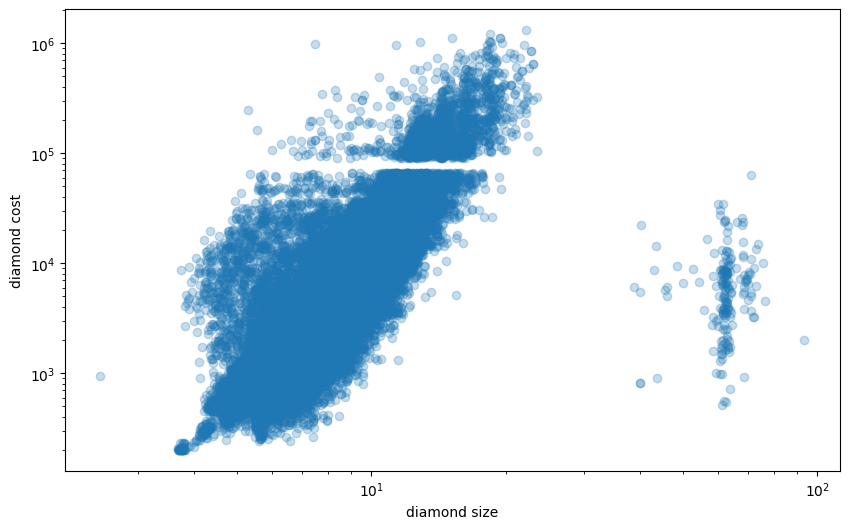

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(train_data['minkowski_sum'], train_data['total_sales_price'], alpha=0.25)
plt.xlabel('diamond size')
plt.ylabel('diamond cost')
plt.yscale('log')
plt.xscale('log')
plt.show()

(2 балла) Нанесите на тот же график тестовую выборку, используя другой цвет (не забудьте про параметр прозрачности):

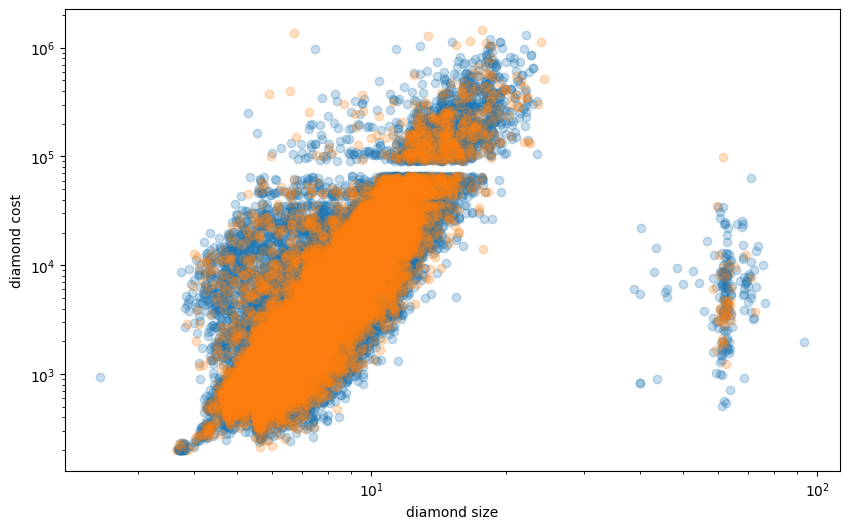

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(train_data['minkowski_sum'], train_data['total_sales_price'], alpha=0.25)
plt.scatter(test_data['minkowski_sum'], test_data['total_sales_price'], alpha=0.25)
plt.xlabel('diamond size')
plt.ylabel('diamond cost')
plt.yscale('log')
plt.xscale('log')
plt.show()

(3 балла) Найдите для каждой бриллианта из тестовой выборки его "ближайшего соседа" из тренинг-выборки. Для каждого бриллианта из тестовой выборки найдите расстояния до соответствующего ближайшего соседа:

In [ ]:
# your code here

(3 балла) Найдите насколько сильно (в процентах) отличается цена бриллиантов из тестовой выборки от их соответствующих ближайших соседей:

In [ ]:
# your code here

**Данная модель является выдумкой автора. Не важен коэффициент ошибки, важны ваши шаги для получения коэффициента.**

### Введение в машинное обучение

Теперь давайте познакомимся с таким сильным инструментом как `sklearn`.

Вам необходимо:
1. выбрать 2 категориальных признака
2. на их основе обучить решающее дерево
3. оценить среднеквадратичную ошибку цены бриллианта
4. сделать пп. 1-3 и выбрать ту пару, которая дает лучший результат
5. сделать выводы

(3 балла) Мы работаем с категориальными признаками, для них не понятно что есть "больше" и "меньше". Поэтому нам нужно предварительно закодировать значения наших признаков, с чем нам поможет [OneHotEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html):

In [ ]:
# your code here

(3 балла) Разбейте датасет на обучающую и тестовую выбору. Для этого вам поможет [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html):

In [ ]:
# your code here

(3 балла) Затем создайте и обучите вашу модель - [DecisionTreeRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html):

In [ ]:
# your code here

(3 балла) Оцените ошибку вашей модели при помощи [mean_squared_error](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html):

In [ ]:
# your code here

(3 балла) **Сделайте выводы какие категориальные признаки лучше:**

*Подсказки для маленьких: Что вы можете сказать о зависимости по вашей выборке признаков? Какой вы можете сделать вывод об готовых инструментах для работы и написанных Вами?*

Ваши выводы здесь :)